# Stack Overflow Post Data Analysis

## 1. Overview

- The JSON file contains records of posts from a Q&A platform (similar to Stack Overflow). Each record corresponds to a single post, which can be either a question or an answer. The dataset includes metadata about the post (ID, type, creation date), user information, content, and community interaction metrics.

## 2. Data Structure and Key Fields

### 2.1. Identification and Classification

- **Id**: Unique identifier of the post.
- **PostTypeId**: Defines the type of the post:
    - "1" → Question
    - "2" → Answer
- **ParentId**: Only present for answers, referencing the ID of the parent question.

### 2.2. Content Information

- **Title**: Title of the post (only for questions).
- **Body**: Main content of the post, typically in HTML format, which may include paragraphs, code snippets, and formatted text.
- **Tags**: List of topic tags, separated by |, describing the subject areas of the post.

### 2.3. Community Interaction Metrics

- **Score**: Net score of the post (upvotes – downvotes).
- **ViewCount**: Number of times the question was viewed (only for questions).
- **AnswerCount**: Number of answers associated with a question.
- **CommentCount**: Number of comments made on the post.

### 2.4. User and System Metadata

- **CreationDate**: Timestamp (ISO 8601 format) indicating when the post was created.
- **OwnerUserId**: User ID of the author of the post.

## 3. Inport library

In [1]:
import os
import re
import json
import html
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import chain
from bs4 import BeautifulSoup

In [2]:
input_path = r"./raw_data/posts_1_5M.json"

In [3]:
with open(input_path, "r", encoding="utf-8") as f:
    data = json.load(f)

In [4]:
df_post = pd.DataFrame(data)
df_post.head()

,Id,PostTypeId,Title,Body,Tags,Score,ViewCount,AnswerCount,CommentCount,CreationDate,OwnerUserId,ParentId
0,38779,1,What SPN do I need to set for a net.tcp service?,<p>I have a wcf application hosted in a window...,|wcf|security|spn|,6,6282,2,0,2008-09-02T03:41:06.880,781,NaN
1,38781,2,NaN,"<p>Agda 2: Functional, dependently typed.</p>\...",NaN,3,NaN,NaN,0,2008-09-02T03:44:26.013,3434,23930
2,38784,1,Visual Studio equivalent to Delphi bookmarks,<p>I use <strong>Delphi</strong> for many year...,|visual-studio|delphi|brief-bookmarks|,7,3474,8,1,2008-09-02T03:49:17.920,4149,NaN
3,38785,2,NaN,<p><kbd>Ctrl</kbd> <kbd>K</kbd> + <kbd>Ctrl</k...,NaN,4,NaN,NaN,1,2008-09-02T03:54:14.587,380,38784
4,38787,2,NaN,<p>MPP does have its own object model that can...,NaN,3,NaN,NaN,0,2008-09-02T03:58:41.830,380,38769


## 4. Classifying questions and answers

In [5]:
df_questions = df_post[df_post["PostTypeId"] == "1"]
df_answers = df_post[df_post["PostTypeId"] == "2"]

In [6]:
print("Number of questions: ", len(df_questions))
print("Number of answers: ", len(df_answers))

Number of questions:  388768
Number of answers:  1111232


- Export to JSON file:

In [7]:
raw_data_questions_path = r"./raw_data/raw_data_questions.json"
raw_data_answers_path = r"./raw_data/raw_data_answers.json"

In [8]:
# Save questions if file does not exist
if not os.path.exists(raw_data_questions_path):
    df_questions.to_json(raw_data_questions_path, orient="records", indent=2, force_ascii=False)
    print(f"File created: {raw_data_questions_path}")
else:
    print(f"File already exists: {raw_data_questions_path}. Skipping creation.")

# Save answers if file does not exist
if not os.path.exists(raw_data_answers_path):
    df_answers.to_json(raw_data_answers_path, orient="records", indent=2, force_ascii=False)
    print(f"File created: {raw_data_answers_path}")
else:
    print(f"File already exists: {raw_data_answers_path}. Skipping creation.")

File already exists: ./raw_data/raw_data_questions.json. Skipping creation.
File already exists: ./raw_data/raw_data_answers.json. Skipping creation.


## 5. Tag analysis

- The function extract_tags takes a string of tags (separated by |) and returns them as a list.

In [9]:
def extract_tags(tag_str):
    if pd.isna(tag_str):
        return []
    return [t for t in tag_str.strip("|").split("|") if t]

- Generate a column containing tag lists

In [10]:
df_post["TagList"] = df_post["Tags"].apply(extract_tags)

In [11]:
df_post.head()

,Id,PostTypeId,Title,Body,Tags,Score,ViewCount,AnswerCount,CommentCount,CreationDate,OwnerUserId,ParentId,TagList
0,38779,1,What SPN do I need to set for a net.tcp service?,<p>I have a wcf application hosted in a window...,|wcf|security|spn|,6,6282,2,0,2008-09-02T03:41:06.880,781,NaN,"[wcf, security, spn]"
1,38781,2,NaN,"<p>Agda 2: Functional, dependently typed.</p>\...",NaN,3,NaN,NaN,0,2008-09-02T03:44:26.013,3434,23930,[]
2,38784,1,Visual Studio equivalent to Delphi bookmarks,<p>I use <strong>Delphi</strong> for many year...,|visual-studio|delphi|brief-bookmarks|,7,3474,8,1,2008-09-02T03:49:17.920,4149,NaN,"[visual-studio, delphi, brief-bookmarks]"
3,38785,2,NaN,<p><kbd>Ctrl</kbd> <kbd>K</kbd> + <kbd>Ctrl</k...,NaN,4,NaN,NaN,1,2008-09-02T03:54:14.587,380,38784,[]
4,38787,2,NaN,<p>MPP does have its own object model that can...,NaN,3,NaN,NaN,0,2008-09-02T03:58:41.830,380,38769,[]


- Count the frequency of each tag

In [12]:
tag_counter = Counter(chain.from_iterable(df_post["TagList"]))
tag_counts = pd.Series(tag_counter).sort_values(ascending=False)

In [13]:
print("Number of subject: ", len(tag_counts))
print("Top 10 tags:", tag_counts.head(10).to_dict())

Number of subject:  18669
Top 10 tags: {'c#': 52305, '.net': 28379, 'java': 27490, 'asp.net': 23288, 'php': 21658, 'javascript': 20841, 'c++': 18313, 'jquery': 14928, 'python': 14480, 'sql': 13508}


- Export subject CSV file

In [14]:
tag_counts_path = r"./raw_data/tag_counts.csv"

In [15]:
if not os.path.exists(tag_counts_path):
    tag_counts.to_csv(tag_counts_path, header=["count"])
    print(f"File created: {tag_counts_path}")
else:
    print(f"File already exists: {tag_counts_path}. Skipping creation.")

File already exists: ./raw_data/tag_counts.csv. Skipping creation.


- Draw a bar chart (limited to top 20 entries)

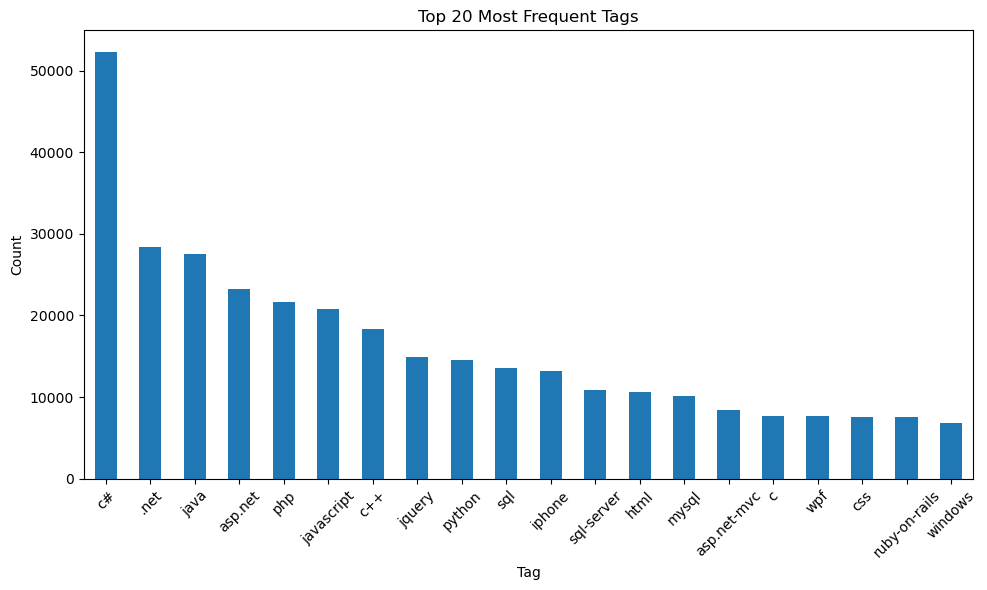

In [16]:
plt.figure(figsize=(10,6))
tag_counts.head(20).plot(kind="bar")
plt.title("Top 20 Most Frequent Tags")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Normalize the 'body' attribute

- Normalize the 'Body' attribute:
    - Remove presentation tags such as `<p>`, `<div>`, `<br>`, etc.
    - Distinguish between code blocks `<pre><code>` and inline code `<code>`
    - Convert `<a>` links to [[LINK:URL]]
    - Convert `<kbd>` shortcuts to [[KEY]] ... [[/KEY]]
    - Decode HTML entities (&gt;, &lt;, &amp;)

In [17]:
def split_body(body_html: str):
    if not body_html:
        return "", ""

    soup = BeautifulSoup(body_html, "html.parser")
    text_parts = []
    code_parts = []

    # --- Handle code blocks ---
    for pre in soup.find_all("pre"):
        code_block = pre.get_text("\n", strip=True)
        code_parts.append(code_block)
        pre.decompose()  # remove from soup

    # --- Handle inline code ---
    for code in soup.find_all("code"):
        code_text = code.get_text(strip=True)
        code.replace_with(f"`{code_text}`")


    # --- Handle links ---
    for a in soup.find_all("a"):
        href = a.get("href", "")
        text = a.get_text(strip=True)
        a.replace_with(f"{text} ({href})" if href else text)

    # --- Handle keyboard shortcuts ---
    for kbd in soup.find_all("kbd"):
        key_text = kbd.get_text(strip=True)
        kbd.replace_with(f"[{key_text}]")

    # --- Extract text ---
    text = soup.get_text("\n", strip=True)
    text = html.unescape(text)
    text = " ".join(text.split())
    text_parts.append(text)

    return " ".join(text_parts).strip(), "\n".join(code_parts).strip()

- Export the normalized data to a JSON file, excluding the 'Tags' field since 'TagList' is already available, and split the 'Body' column into 'BodyText' and 'BodyCode' to support AI Chatbox development.

In [18]:
df_post["BodyText"], df_post["BodyCode"] = zip(*df_post["Body"].map(split_body))

In [19]:
df_post = df_post.drop(columns=["Body", "Tags"], errors="ignore")

In [27]:
output_Section_6_path = r"../dataset/post.jsonl"

- Clean surrogate characters from the DataFrame prior to export:

In [28]:
def clean_text(s):
    if isinstance(s, str):
        return re.sub(r'[\ud800-\udfff]', '', s)
    return s

In [29]:
df_post = df_post.applymap(clean_text)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5652\3325237407.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_post = df_post.applymap(clean_text)


In [30]:
def save_jsonl(df, output_path):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    with open(output_path, "w", encoding="utf-8") as f:
        for _, row in df.iterrows():
            record = row.to_dict()
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
    print(f"Saved {len(df)} records to {output_path}")

In [31]:
save_jsonl(df_post, output_Section_6_path)

Saved 1500000 records to ../dataset/post.jsonl


## 7. Merge the data and write to a new file.

In [32]:
questions = {}
best_answers = {}

In [34]:
with open(output_Section_6_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            post = json.loads(line)
            post_type = post.get("PostTypeId")

            if post_type == "1":
                qid = post.get("Id")
                questions[qid] = {
                    "Id": qid,
                    "Title": post.get("Title"),
                    "TagList": post.get("TagList", []),
                    "Question": {
                        "BodyText": post.get("BodyText", ""),
                        "BodyCode": post.get("BodyCode", "")
                    },
                    "Score": int(post.get("Score", 0))
                }

            elif post_type == "2":
                parent_id = post.get("ParentId")
                if not parent_id:
                    continue
                score = int(post.get("Score", 0))

                if parent_id not in best_answers or score > best_answers[parent_id]["Score"]:
                    best_answers[parent_id] = {
                        "BodyText": post.get("BodyText", ""),
                        "BodyCode": post.get("BodyCode", ""),
                        "Score": score
                    }

        except Exception as e:
            continue

In [35]:
output_file = r"../dataset/merged_posts.jsonl"

In [36]:
with open(output_file, "w", encoding="utf-8") as out:
    for qid, qdata in questions.items():
        answer = best_answers.get(qid, None)
        merged = {
            "Id": qdata["Id"],
            "Title": qdata["Title"],
            "TagList": qdata["TagList"],
            "Question": qdata["Question"],
            "Answer": {
                "BodyText": answer["BodyText"] if answer else "",
                "BodyCode": answer["BodyCode"] if answer else ""
            },
            "Score": qdata["Score"]
        }
        out.write(json.dumps(merged, ensure_ascii=False) + "\n")

print("Data merge completed! Output file: ", output_file)

Data merge completed! Output file:  ../dataset/merged_posts.jsonl


In [42]:
def check_empty_bodycode(file_path):
    non_empty_examples = []
    total = 0
    non_empty_count = 0

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            total += 1
            try:
                data = json.loads(line)
                body_code = data.get("Question", {}).get("BodyCode", "")
                if body_code.strip():
                    non_empty_count += 1
                    if len(non_empty_examples) < 5:
                        non_empty_examples.append({
                            "Id": data.get("Id"),
                            "BodyCode": body_code[:100]
                        })
            except json.JSONDecodeError:
                print(f"Error: {total}")
                continue

    print(f"Total number of rows: {total}")
    print(f"Number of rows with non-empty Question.BodyCode: {non_empty_count}")

    if non_empty_examples:
        print("\n Examples of rows with non-empty BodyCode:")
        for ex in non_empty_examples:
            print(f"  Id: {ex['Id']}, BodyCode (the first 100 characters): {ex['BodyCode']}")
        return False

    return True


In [43]:
result = check_empty_bodycode(output_file)

if result:
    print("All Question.BodyCode fields are empty.")
else:
    print("There are some rows where Question.BodyCode is not empty.")

Total number of rows: 388768
Number of rows with non-empty Question.BodyCode: 165459

 Examples of rows with non-empty BodyCode:
  Id: 38789, BodyCode (the first 100 characters): [WebService(Namespace = "http://dev.mycompany.com/MyAppsWebService")]
[WebService(Namespace = "http:
  Id: 38791, BodyCode (the first 100 characters): "Users (UserID, UserName, CompamyId)"
"Companies (CompamyId, CompanyName)"
"Users (UserID, UserName)
  Id: 38820, BodyCode (the first 100 characters): public class User
{
    public String UserName;
    public String Password;
    public String FirstN
  Id: 38875, BodyCode (the first 100 characters): <?php
  if ( isset( $ _GET['page'] ) ) {
    include( $ _GET['page'] . ".php" );
  } else {
    incl
  Id: 38920, BodyCode (the first 100 characters): PHP Warning: mail() [function.mail]: SMTP server response: 550 5.7.1 Unable to relay for chris.mahan
There are some rows where Question.BodyCode is not empty.
